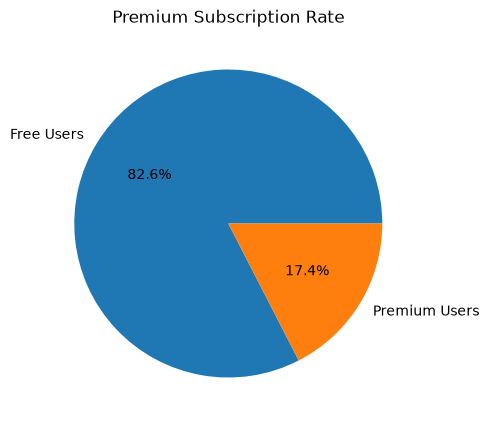

In [41]:
subscription_rate = pd.Series({
    "Free Users": len(users) - len(subscriptions),
    "Premium Users": len(subscriptions)
})

subscription_rate.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Premium Subscription Rate")
plt.show()

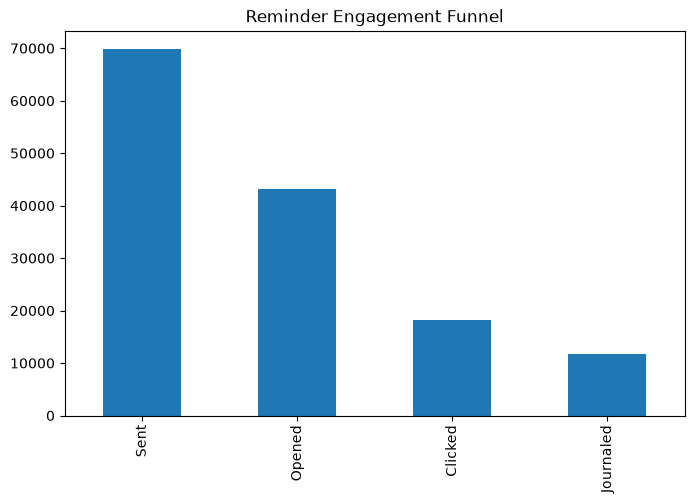

In [40]:
funnel = {
    "Sent": len(reminders),
    "Opened": reminders["opened"].sum(),
    "Clicked": reminders["clicked"].sum(),
    "Journaled": reminders["journaled_after"].sum()
}

pd.Series(funnel).plot(kind="bar")

plt.title("Reminder Engagement Funnel")
plt.show()

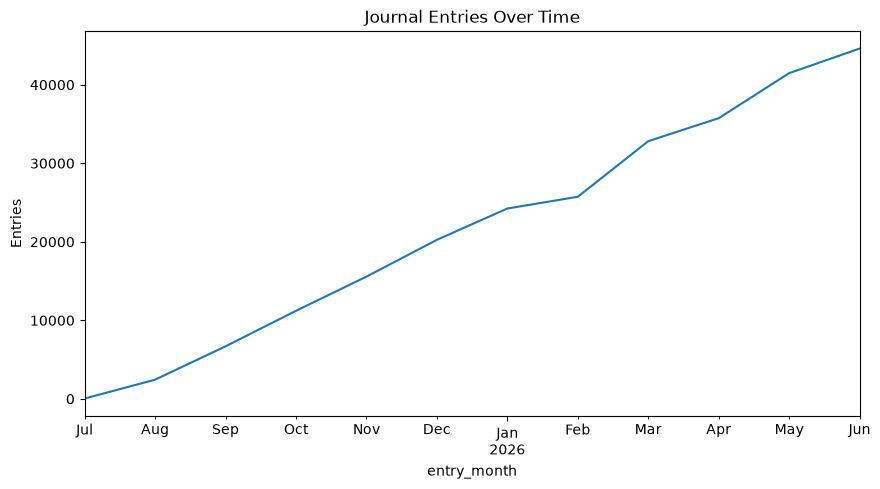

In [38]:
journal["entry_date"] = pd.to_datetime(journal["entry_date"])

journal["entry_month"] = journal["entry_date"].dt.to_period("M")

journal.groupby("entry_month").size().plot(figsize=(10,5))

plt.title("Journal Entries Over Time")
plt.ylabel("Entries")
plt.show()

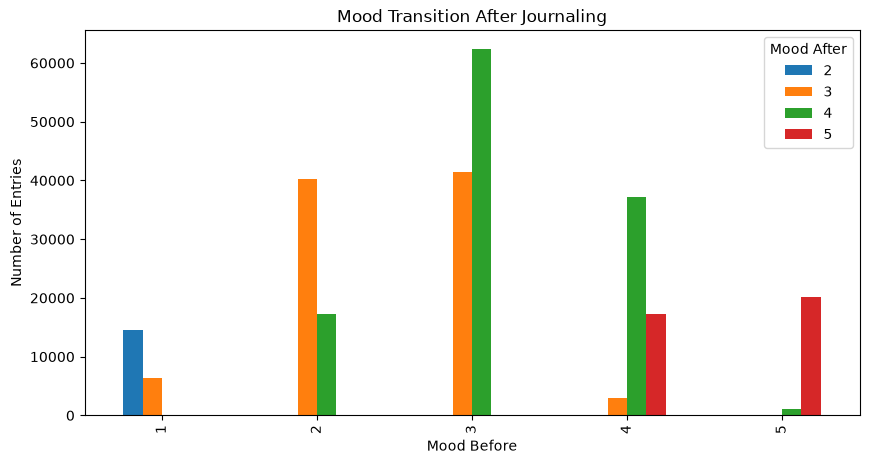

In [37]:
pd.crosstab(
    journal["mood_before"],
    journal["mood_after"]
).plot(kind="bar", figsize=(10,5))

plt.title("Mood Transition After Journaling")
plt.xlabel("Mood Before")
plt.ylabel("Number of Entries")
plt.legend(title="Mood After")
plt.show()

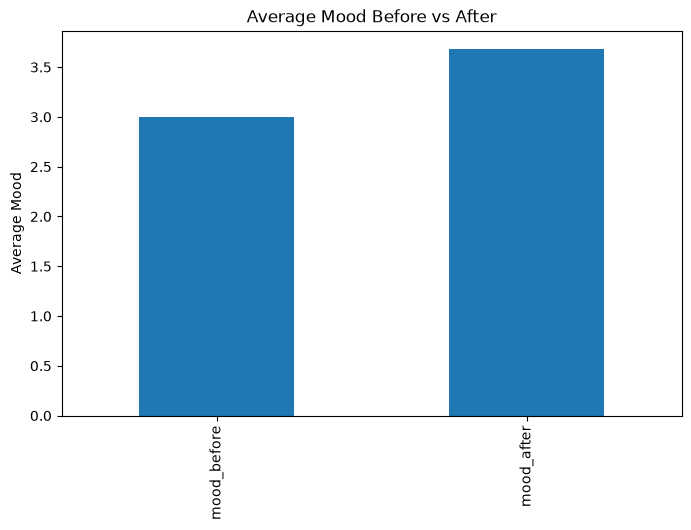

In [33]:
avg = journal[["mood_before","mood_after"]].mean()

avg.plot(kind="bar")

plt.title("Average Mood Before vs After")
plt.ylabel("Average Mood")
plt.show()

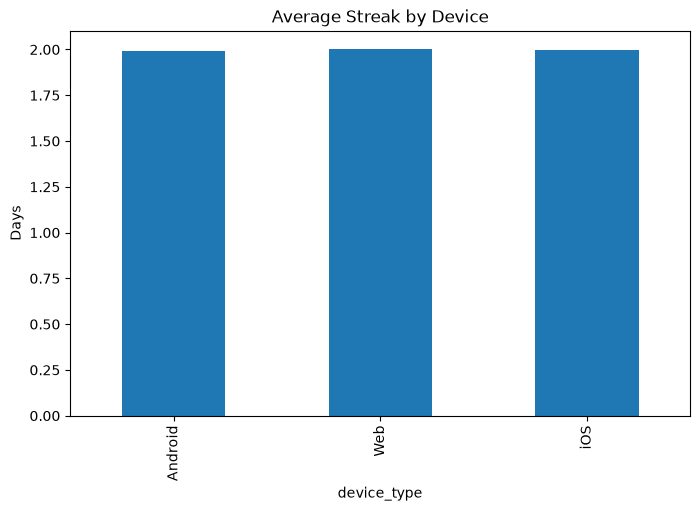

In [32]:
journal.groupby("device_type")["streak_at_entry"].mean().plot(kind="bar")

plt.title("Average Streak by Device")
plt.ylabel("Days")
plt.show()

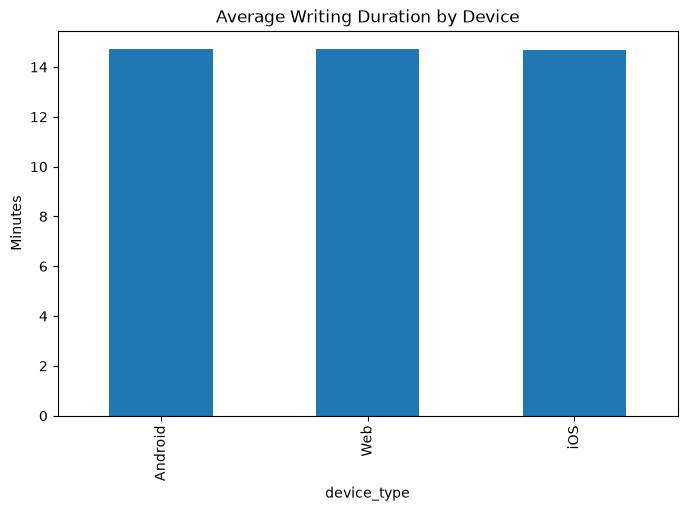

In [31]:
journal.groupby("device_type")["writing_duration_minutes"].mean().plot(kind="bar")

plt.title("Average Writing Duration by Device")
plt.ylabel("Minutes")
plt.show()

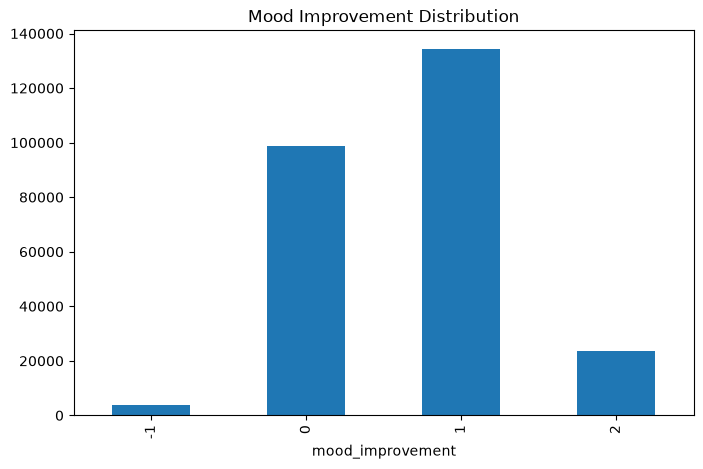

In [30]:
journal["mood_improvement"] = (
    journal["mood_after"] - journal["mood_before"]
)

journal["mood_improvement"].value_counts().sort_index().plot(kind="bar")

plt.title("Mood Improvement Distribution")
plt.show()

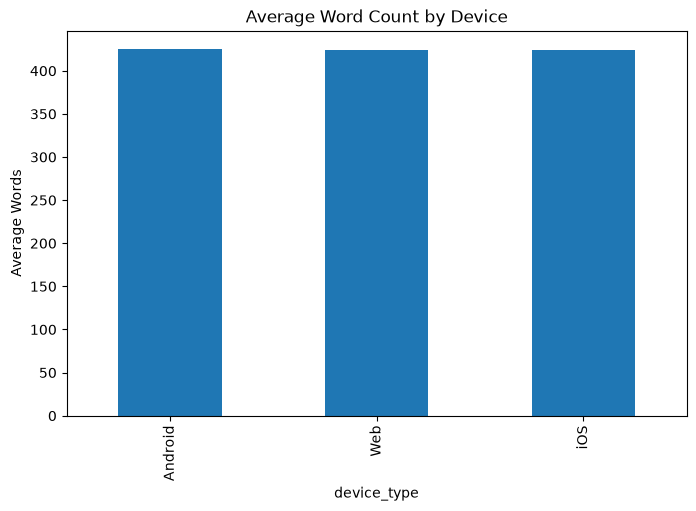

In [29]:
journal.groupby("device_type")["word_count"].mean().plot(kind="bar")

plt.title("Average Word Count by Device")
plt.ylabel("Average Words")
plt.show()

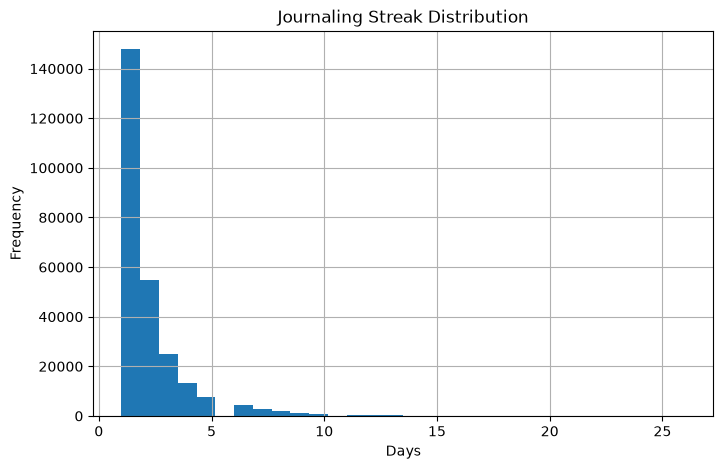

In [28]:
journal["streak_at_entry"].hist(bins=30)

plt.title("Journaling Streak Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

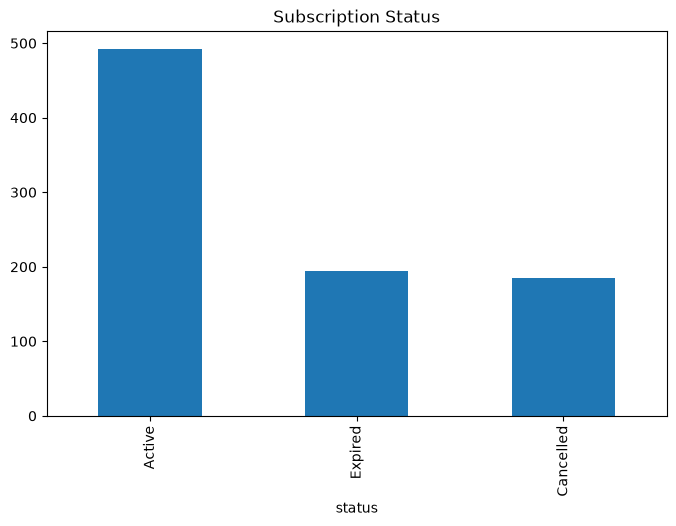

In [27]:
subscriptions["status"].value_counts().plot(kind="bar")

plt.title("Subscription Status")
plt.show()

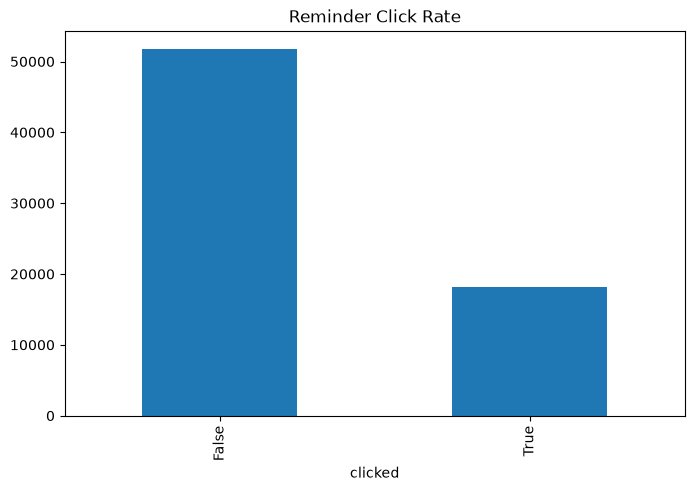

In [26]:
reminders["clicked"].value_counts().plot(kind="bar")

plt.title("Reminder Click Rate")
plt.show()

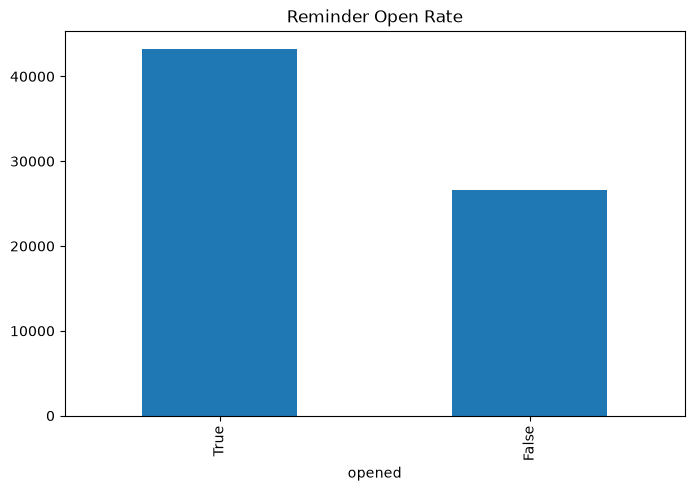

In [25]:
reminders["opened"].value_counts().plot(kind="bar")

plt.title("Reminder Open Rate")
plt.show()

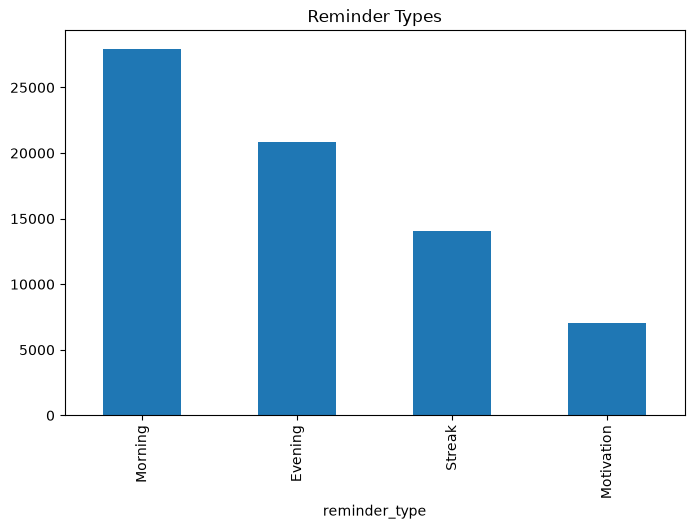

In [24]:
reminders["reminder_type"].value_counts().plot(kind="bar")

plt.title("Reminder Types")
plt.show()

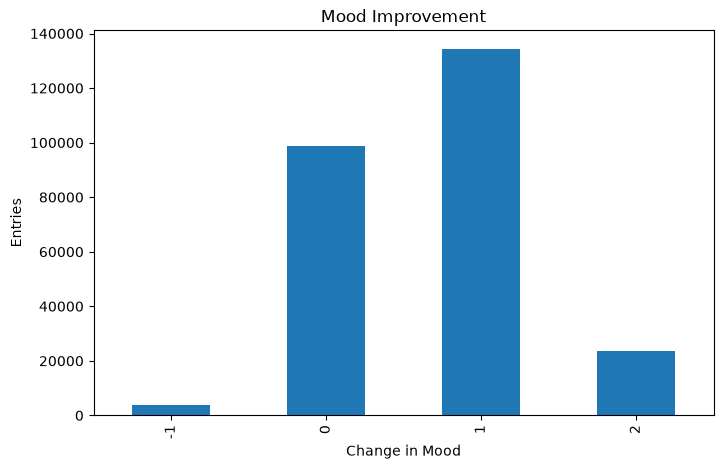

In [23]:
mood_change = journal["mood_after"] - journal["mood_before"]

mood_change.value_counts().sort_index().plot(kind="bar")

plt.title("Mood Improvement")
plt.xlabel("Change in Mood")
plt.ylabel("Entries")
plt.show()

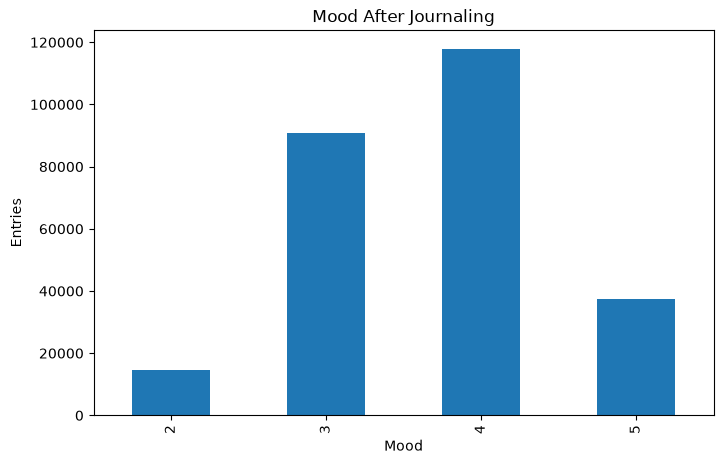

In [22]:
journal["mood_after"].value_counts().sort_index().plot(kind="bar")

plt.title("Mood After Journaling")
plt.xlabel("Mood")
plt.ylabel("Entries")
plt.show()

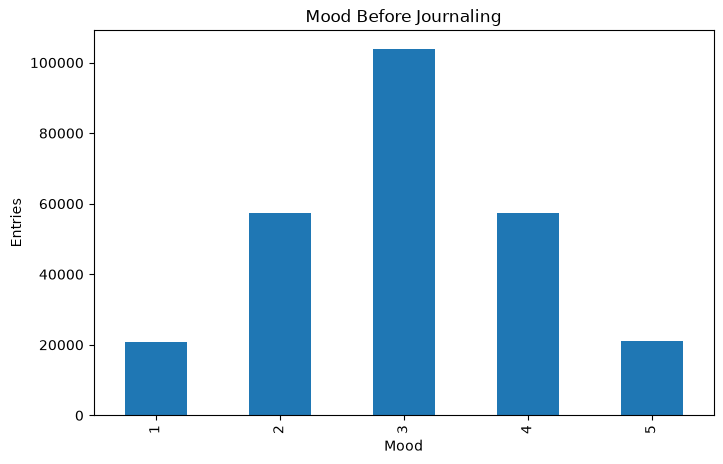

In [21]:
journal["mood_before"].value_counts().sort_index().plot(kind="bar")

plt.title("Mood Before Journaling")
plt.xlabel("Mood")
plt.ylabel("Entries")
plt.show()

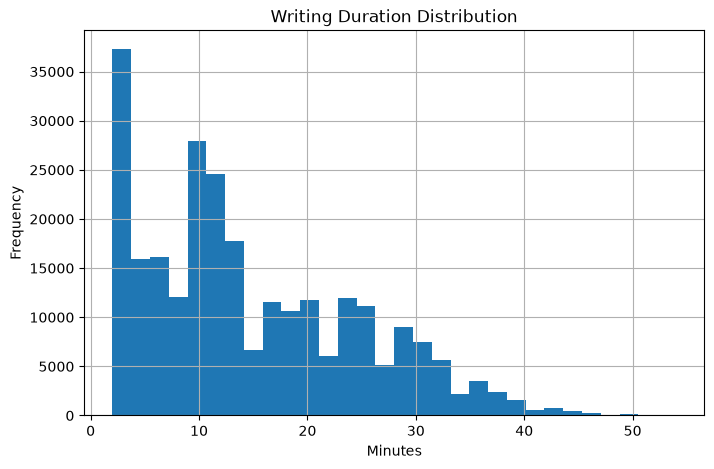

In [20]:
journal["writing_duration_minutes"].hist(bins=30)

plt.title("Writing Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

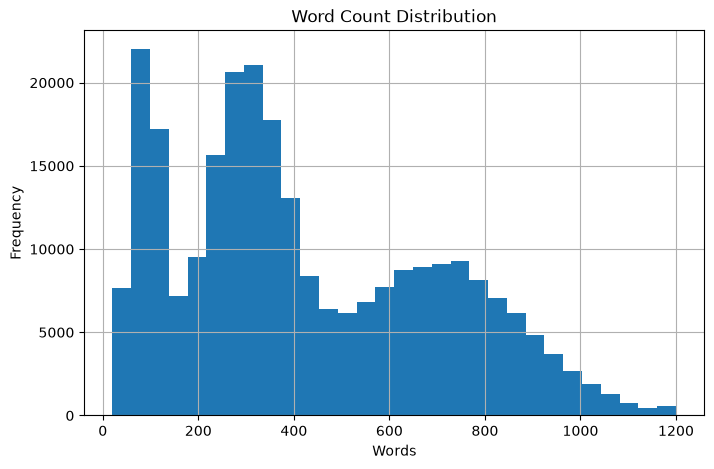

In [19]:
journal["word_count"].hist(bins=30)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

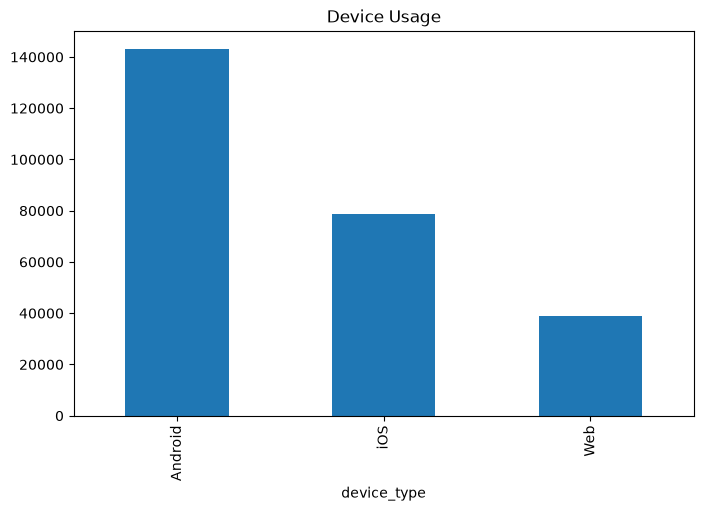

In [18]:
journal["device_type"].value_counts().plot(kind="bar")

plt.title("Device Usage")
plt.show()

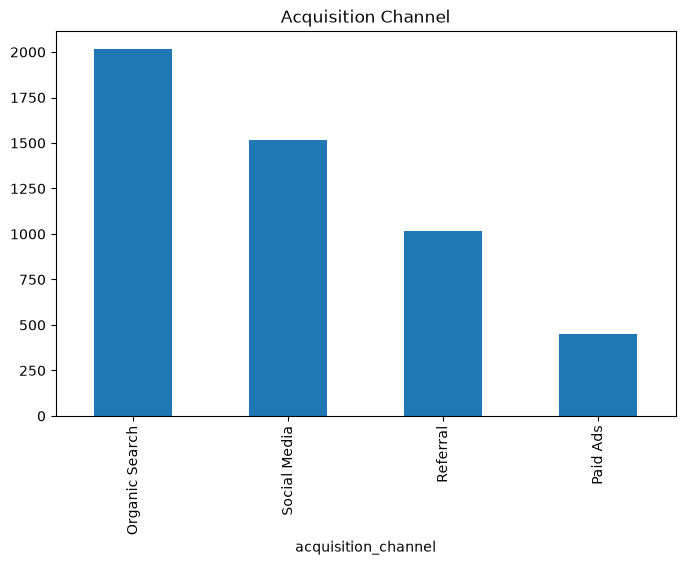

In [17]:
users["acquisition_channel"].value_counts().plot(kind="bar")

plt.title("Acquisition Channel")
plt.show()

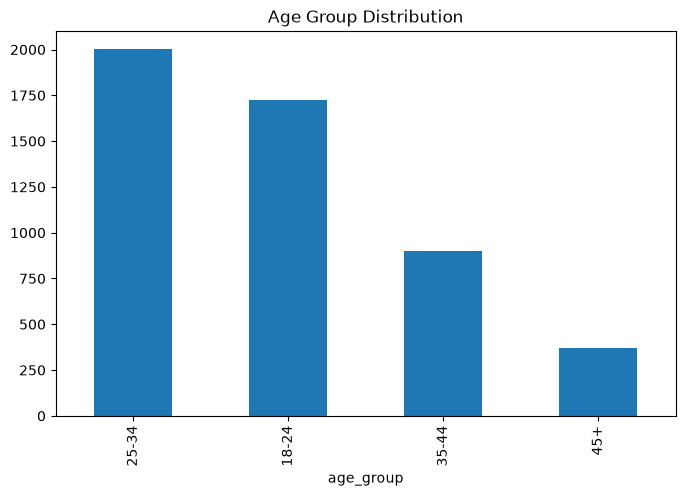

In [16]:
users["age_group"].value_counts().plot(kind="bar")

plt.title("Age Group Distribution")
plt.show()

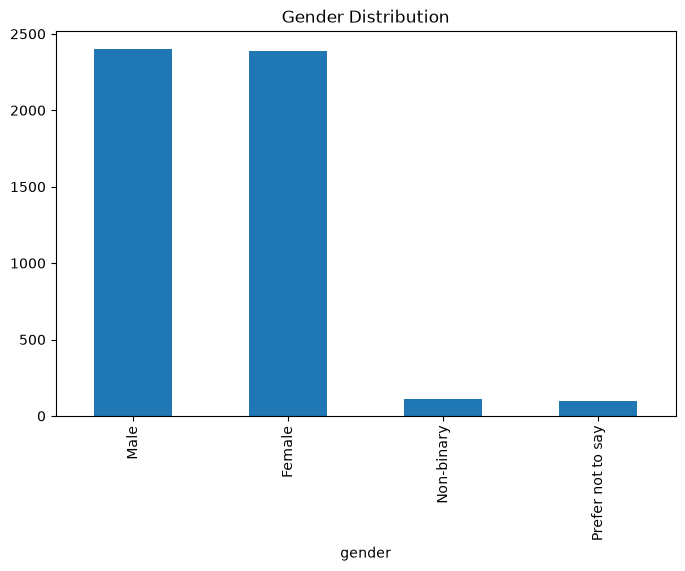

In [15]:
users["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.show()

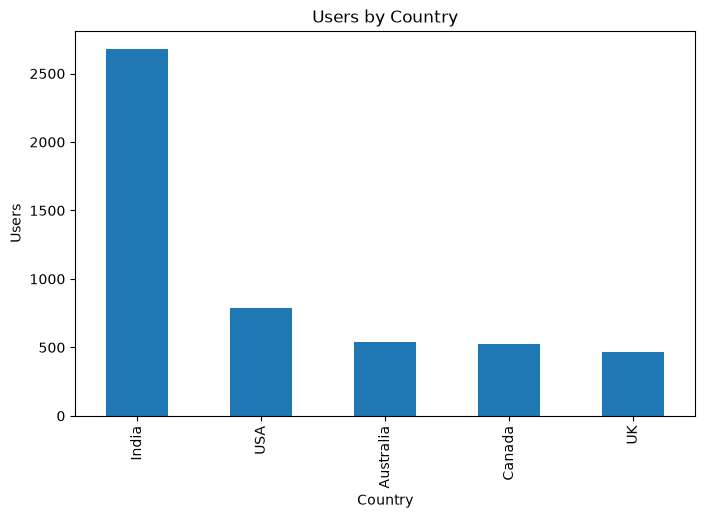

In [14]:
users["country"].value_counts().plot(kind="bar")

plt.title("Users by Country")
plt.xlabel("Country")
plt.ylabel("Users")
plt.show()

In [13]:
print("Users:", users.duplicated().sum())
print("Journal:", journal.duplicated().sum())
print("Reminders:", reminders.duplicated().sum())
print("Subscriptions:", subscriptions.duplicated().sum())

Users: 0
Journal: 0
Reminders: 0
Subscriptions: 0


In [12]:
print(users.isnull().sum())
print()

print(journal.isnull().sum())
print()

print(reminders.isnull().sum())
print()

print(subscriptions.isnull().sum())

user_id                0
signup_date            0
age_group              0
country                0
gender                 0
acquisition_channel    0
dtype: int64

entry_id                    0
user_id                     0
entry_date                  0
entry_time                  0
word_count                  0
mood_before                 0
mood_after                  0
writing_duration_minutes    0
used_prompt                 0
device_type                 0
streak_at_entry             0
dtype: int64

reminder_id        0
user_id            0
reminder_date      0
reminder_type      0
opened             0
clicked            0
journaled_after    0
dtype: int64

subscription_id      0
user_id              0
plan_type            0
start_date           0
end_date           492
status               0
dtype: int64


In [11]:
subscriptions.info()

<class 'pandas.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   subscription_id  872 non-null    int64
 1   user_id          872 non-null    int64
 2   plan_type        872 non-null    str  
 3   start_date       872 non-null    str  
 4   end_date         380 non-null    str  
 5   status           872 non-null    str  
dtypes: int64(2), str(4)
memory usage: 41.0 KB


In [10]:
reminders.info()

<class 'pandas.DataFrame'>
RangeIndex: 69881 entries, 0 to 69880
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   reminder_id      69881 non-null  int64
 1   user_id          69881 non-null  int64
 2   reminder_date    69881 non-null  str  
 3   reminder_type    69881 non-null  str  
 4   opened           69881 non-null  bool 
 5   clicked          69881 non-null  bool 
 6   journaled_after  69881 non-null  bool 
dtypes: bool(3), int64(2), str(2)
memory usage: 2.3 MB


In [9]:
journal.info()

<class 'pandas.DataFrame'>
RangeIndex: 260797 entries, 0 to 260796
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   entry_id                  260797 non-null  int64
 1   user_id                   260797 non-null  int64
 2   entry_date                260797 non-null  str  
 3   entry_time                260797 non-null  str  
 4   word_count                260797 non-null  int64
 5   mood_before               260797 non-null  int64
 6   mood_after                260797 non-null  int64
 7   writing_duration_minutes  260797 non-null  int64
 8   used_prompt               260797 non-null  bool 
 9   device_type               260797 non-null  str  
 10  streak_at_entry           260797 non-null  int64
dtypes: bool(1), int64(7), str(3)
memory usage: 20.1 MB


In [8]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              5000 non-null   int64
 1   signup_date          5000 non-null   str  
 2   age_group            5000 non-null   str  
 3   country              5000 non-null   str  
 4   gender               5000 non-null   str  
 5   acquisition_channel  5000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 234.5 KB


In [7]:
subscriptions.head()

,subscription_id,user_id,plan_type,start_date,end_date,status
0,1,1,Premium,2026-07-06,2026-11-06,Expired
1,2,6,Premium,2026-05-03,2026-10-08,Expired
2,3,15,Premium,2026-04-24,2026-09-05,Expired
3,4,18,Premium,2026-05-13,2026-06-18,Cancelled
4,5,19,Premium,2026-08-08,NaN,Active


In [6]:
reminders.head()

,reminder_id,user_id,reminder_date,reminder_type,opened,clicked,journaled_after
0,1,1,2026-06-30,Evening,True,True,True
1,2,1,2026-12-20,Morning,False,False,False
2,3,1,2026-05-01,Evening,False,False,False
3,4,1,2026-12-31,Morning,True,False,False
4,5,1,2026-10-01,Evening,False,False,False


In [5]:
journal.head()

,entry_id,user_id,entry_date,entry_time,word_count,mood_before,mood_after,writing_duration_minutes,used_prompt,device_type,streak_at_entry
0,1,1,2026-03-19,Morning,351,3,4,14,True,iOS,1
1,2,1,2026-03-22,Afternoon,421,2,3,12,True,Android,1
2,3,1,2026-03-24,Morning,262,3,4,10,False,Android,1
3,4,1,2026-03-25,Evening,343,2,3,11,False,Android,2
4,5,1,2026-03-28,Morning,218,3,3,8,False,Android,1


In [4]:
users.head()

,user_id,signup_date,age_group,country,gender,acquisition_channel
0,1,2026-03-19,25-34,India,Male,Organic Search
1,2,2025-08-06,25-34,USA,Female,Organic Search
2,3,2025-11-05,25-34,India,Male,Social Media
3,4,2025-10-17,18-24,India,Female,Social Media
4,5,2026-04-23,18-24,USA,Female,Organic Search


In [3]:
print("Users:", users.shape)
print("Journal Entries:", journal.shape)
print("Reminders:", reminders.shape)
print("Subscriptions:", subscriptions.shape)

Users: (5000, 6)
Journal Entries: (260797, 11)
Reminders: (69881, 7)
Subscriptions: (872, 6)


In [2]:
users = pd.read_csv("../data/raw/users.csv")
journal = pd.read_csv("../data/raw/journal_entries.csv")
reminders = pd.read_csv("../data/raw/reminders.csv")
subscriptions = pd.read_csv("../data/raw/subscriptions.csv")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8,5)